In [1]:
!pip install seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="darkgrid")

In [2]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/planets.csv"
df = pd.read_csv(url)

df = df.dropna()


In [3]:
habitable = df[(df["orbital_period"] > 200) & (df["orbital_period"] < 400)]

print("Total planets:", len(df))
print("Potentially habitable (approx):", len(habitable))

Total planets: 498
Potentially habitable (approx): 59


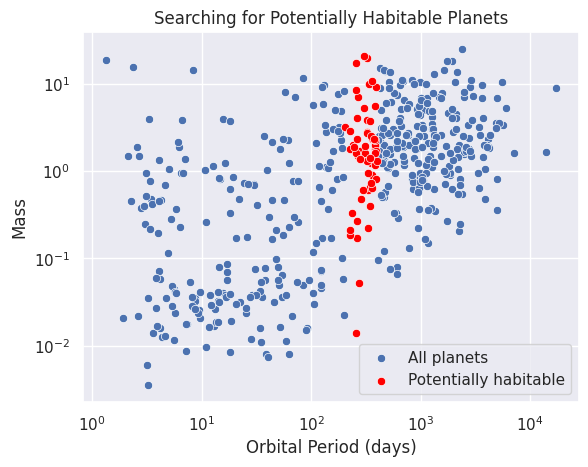

In [4]:
plt.figure()
sns.scatterplot(data=df, x="orbital_period", y="mass", label="All planets")
sns.scatterplot(data=habitable, x="orbital_period", y="mass", color="red", label="Potentially habitable")
plt.xscale("log")
plt.yscale("log")
plt.title("Searching for Potentially Habitable Planets")
plt.xlabel("Orbital Period (days)")
plt.ylabel("Mass")
plt.legend()
plt.show()

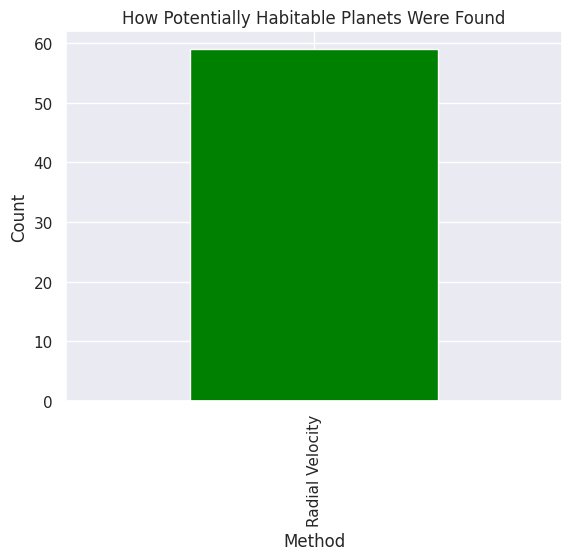

In [5]:
plt.figure()
habitable["method"].value_counts().plot(kind="bar", color="green")
plt.title("How Potentially Habitable Planets Were Found")
plt.xlabel("Method")
plt.ylabel("Count")
plt.show()

In [6]:
!pip install ipywidgets

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ipywidgets import interact, FloatSlider

sns.set(style="darkgrid")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 21.2 MB/s eta 0:00:00


In [7]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/planets.csv"
df = pd.read_csv(url)
df = df.dropna()

In [8]:
def explore_planets(min_period=100, max_period=500, min_mass=0.1, max_mass=10):

    filtered = df[
        (df["orbital_period"] >= min_period) &
        (df["orbital_period"] <= max_period) &
        (df["mass"] >= min_mass) &
        (df["mass"] <= max_mass)
    ]

    print(f"Filtered planets: {len(filtered)}")

    plt.figure()
    sns.scatterplot(data=filtered, x="orbital_period", y="mass")
    plt.xscale("log")
    plt.yscale("log")
    plt.title("Interactive Exoplanet Explorer 🌌")
    plt.xlabel("Orbital Period (days)")
    plt.ylabel("Mass (Jupiter mass)")
    plt.show()

In [9]:
interact(
    explore_planets,
    min_period=FloatSlider(min=0, max=1000, step=10, value=100),
    max_period=FloatSlider(min=100, max=2000, step=50, value=500),
    min_mass=FloatSlider(min=0, max=5, step=0.1, value=0.1),
    max_mass=FloatSlider(min=1, max=20, step=0.5, value=10)
)

interactive(children=(FloatSlider(value=100.0, description='min_period', max=1000.0, step=10.0), FloatSlider(v…

<function __main__.explore_planets(min_period=100, max_period=500, min_mass=0.1, max_mass=10)>